<a href="https://colab.research.google.com/github/parviza9999/Credit-Card-Fraud-Detection-/blob/main/notebooks/01_complete_eda_credit_card_fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Load dataset

In [3]:
import pandas as pd

file_path = "/content/drive/MyDrive/Interview Node/Capstone_Project/Fraud Detection GCP Capstone/data/raw/creditcard.csv"

df = pd.read_csv(file_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


# Dataset shape

In [4]:
df.shape

(284807, 31)

In [5]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [6]:
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.8273
1,0.1727


# Data types and structure

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Except for one Class feature, all data are in float.

# Missing values

In [8]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df)) * 100
})

missing_summary.sort_values("missing_count", ascending=False)

,missing_count,missing_percent
Time,0,0.0000
V1,0,0.0000
V2,0,0.0000
V3,0,0.0000
V4,0,0.0000
V5,0,0.0000
V6,0,0.0000
V7,0,0.0000
V8,0,0.0000
V9,0,0.0000


No missing values found

# Duplicate records

In [9]:
duplicate_count = df.duplicated().sum()
duplicate_percent = duplicate_count / len(df) * 100

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", duplicate_percent)

Duplicate rows: 1081
Duplicate percentage: 0.379555277784605


38% of rows data appear to be duplicate

# Class distribution

In [10]:
class_counts = df["Class"].value_counts().rename(index={0: "Non-Fraud", 1: "Fraud"})
class_percentages = df["Class"].value_counts(normalize=True).rename(index={0: "Non-Fraud", 1: "Fraud"}) * 100

class_distribution = pd.DataFrame({
    "count": class_counts,
    "percent": class_percentages
})

class_distribution

,count,percent
Class,,
Non-Fraud,284315,99.8273
Fraud,492,0.1727


0.17% of data are flagged as fraud

# Class imbalance bar chart

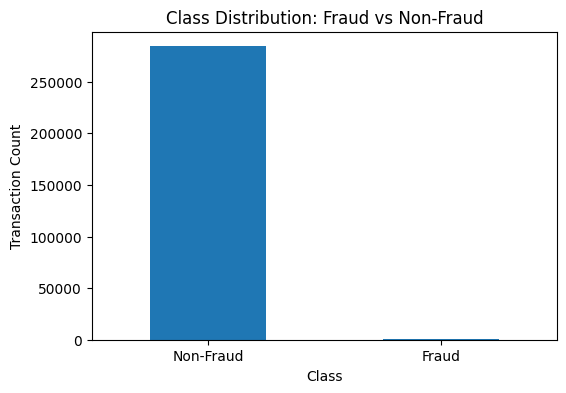

In [11]:
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Class Distribution: Fraud vs Non-Fraud")
plt.xlabel("Class")
plt.ylabel("Transaction Count")
plt.xticks(rotation=0)
plt.show()

# Fraud percentage statement

In [12]:
fraud_count = df[df["Class"] == 1].shape[0]
non_fraud_count = df[df["Class"] == 0].shape[0]
fraud_percent = fraud_count / len(df) * 100

print(f"Fraud transactions: {fraud_count}")
print(f"Non-fraud transactions: {non_fraud_count}")
print(f"Fraud percentage: {fraud_percent:.4f}%")

Fraud transactions: 492
Non-fraud transactions: 284315
Fraud percentage: 0.1727%


# Descriptive statistics

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,"284,807.0000","94,813.8596","47,488.1460",0.0000,"54,201.5000","84,692.0000","139,320.5000","172,792.0000"
V1,"284,807.0000",0.0000,1.9587,-56.4075,-0.9204,0.0181,1.3156,2.4549
V2,"284,807.0000",0.0000,1.6513,-72.7157,-0.5985,0.0655,0.8037,22.0577
V3,"284,807.0000",-0.0000,1.5163,-48.3256,-0.8904,0.1798,1.0272,9.3826
V4,"284,807.0000",0.0000,1.4159,-5.6832,-0.8486,-0.0198,0.7433,16.8753
V5,"284,807.0000",0.0000,1.3802,-113.7433,-0.6916,-0.0543,0.6119,34.8017
V6,"284,807.0000",0.0000,1.3323,-26.1605,-0.7683,-0.2742,0.3986,73.3016
V7,"284,807.0000",-0.0000,1.2371,-43.5572,-0.5541,0.0401,0.5704,120.5895
V8,"284,807.0000",0.0000,1.1944,-73.2167,-0.2086,0.0224,0.3273,20.0072
V9,"284,807.0000",-0.0000,1.0986,-13.4341,-0.6431,-0.0514,0.5971,15.5950


# Amount summary by class

In [14]:
amount_by_class = df.groupby("Class")["Amount"].describe()
amount_by_class

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,"284,315.0000",88.2910,250.1051,0.0000,5.6500,22.0000,77.0500,"25,691.1600"
1,492.0000,122.2113,256.6833,0.0000,1.0000,9.2500,105.8900,"2,125.8700"


# Amount distribution

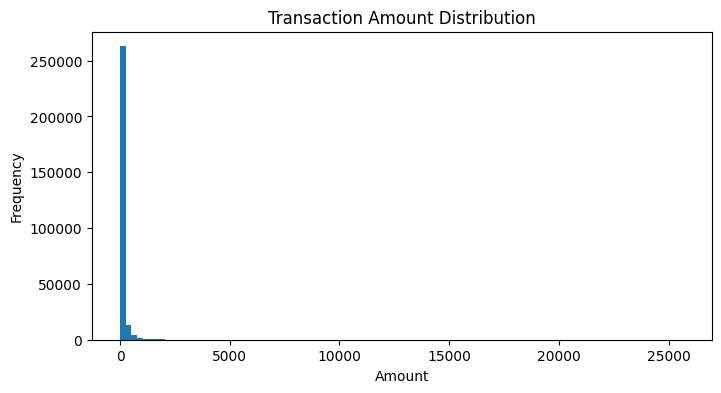

In [15]:
plt.figure(figsize=(8, 4))
df["Amount"].plot(kind="hist", bins=100)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Log amount distribution

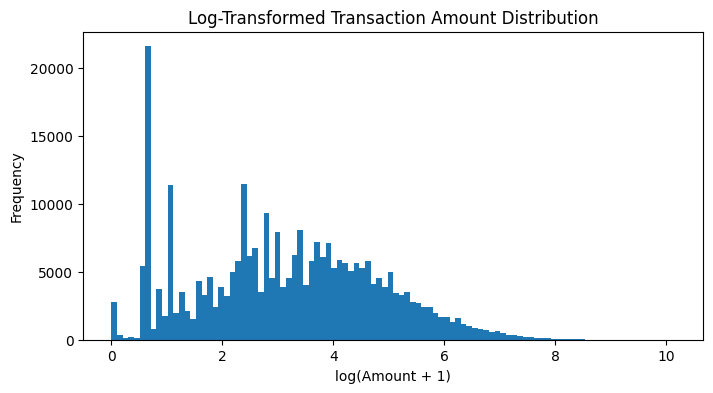

In [16]:
df["Log_Amount"] = np.log1p(df["Amount"])

plt.figure(figsize=(8, 4))
df["Log_Amount"].plot(kind="hist", bins=100)
plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Frequency")
plt.show()

# Time distribution

## Transaction Time Distribution Interpretation

The transaction time distribution often reveals patterns in transaction activity. For this dataset, the 'Time' feature represents the seconds elapsed between each transaction and the first transaction in the dataset. A typical distribution might show:

*   **Peaks of Activity**: There might be noticeable peaks indicating periods of high transaction volume, possibly corresponding to active hours of the day or specific days of the week.
*   **Bimodal/Multimodal Distribution**: Often, time-based transaction data can be bimodal (two peaks) or multimodal (multiple peaks), reflecting different cycles of activity, such as day and night cycles over a 48-hour period (if 'Time' spans two days).
*   **Relatively Flat Periods**: There could also be periods of low transaction activity.

Understanding these patterns can be useful for feature engineering (e.g., creating 'hour of day' or 'day of week' features) and for identifying anomalies in transaction timing.

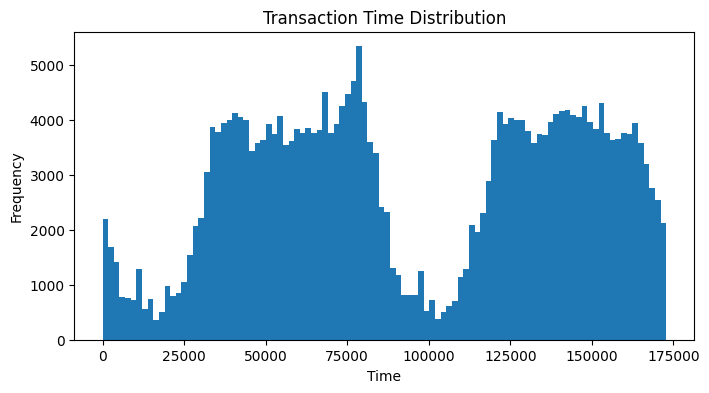

In [17]:
plt.figure(figsize=(8, 4))
df["Time"].plot(kind="hist", bins=100)
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

## Analyzing Transaction Volume by Hour

To understand transaction patterns throughout the day, I will convert the 'Time' feature (seconds elapsed since the first transaction) into 'hour_of_day'. This will help us identify peak transaction periods.

/tmp/ipykernel_3046/1234033609.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['hour_of_day'], bins=24, kde=False, palette='viridis')


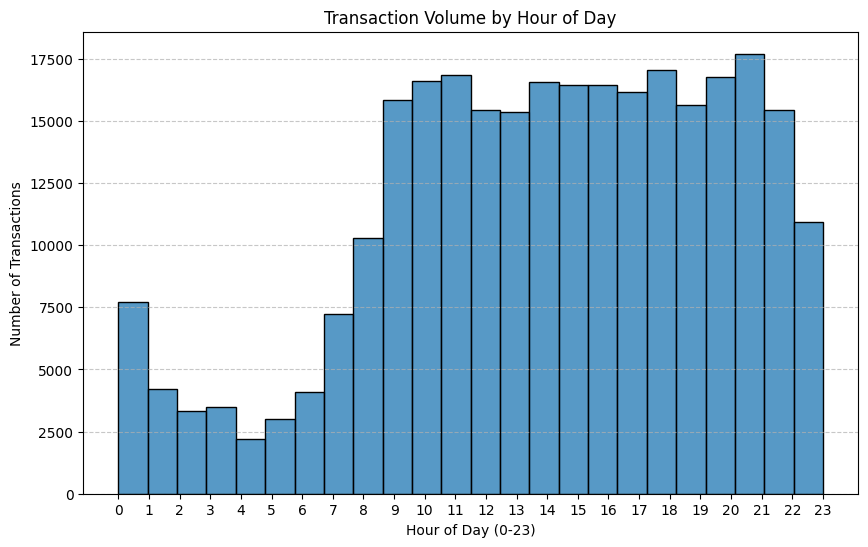

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

df['hour_of_day'] = (df['Time'] % (24 * 3600)) // 3600

plt.figure(figsize=(10, 6))
sns.histplot(df['hour_of_day'], bins=24, kde=False, palette='viridis')
plt.title('Transaction Volume by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [27]:
hourly_transactions = df['hour_of_day'].value_counts().sort_index()
display(hourly_transactions.head())

peak_hours = hourly_transactions.nlargest(5)
print('\nTop 5 high transaction volume hours:')
display(peak_hours)

,count
hour_of_day,
0.0000,7695
1.0000,4220
2.0000,3328
3.0000,3492
4.0000,2209



Top 5 high transaction volume hours:


,count
hour_of_day,
21.0000,17703
18.0000,17039
11.0000,16856
20.0000,16756
10.0000,16598


# Correlation matrix

In [28]:
corr_matrix = df.drop(columns=["Log_Amount"]).corr()

corr_matrix

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hour_of_day
Time,1.0000,0.1174,-0.0106,-0.4196,-0.1053,0.1731,-0.0630,0.0847,-0.0369,-0.0087,0.0306,-0.2477,0.1243,-0.0659,-0.0988,-0.1835,0.0119,-0.0733,0.0904,0.0290,-0.0509,0.0447,0.1441,0.0511,-0.0162,-0.2331,-0.0414,-0.0051,-0.0094,-0.0106,-0.0123,0.4156
V1,0.1174,1.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.2277,-0.1013,-0.0052
V2,-0.0106,0.0000,1.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.5314,0.0913,0.0078
V3,-0.4196,-0.0000,0.0000,1.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.2109,-0.1930,-0.0216
V4,-0.1053,-0.0000,-0.0000,0.0000,1.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0987,0.1334,-0.0351
V5,0.1731,0.0000,0.0000,-0.0000,-0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.3864,-0.0950,-0.0351
V6,-0.0630,-0.0000,0.0000,0.0000,-0.0000,0.0000,1.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.2160,-0.0436,-0.0189
V7,0.0847,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.3973,-0.1873,-0.0097
V8,-0.0369,-0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,1.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.1031,0.0199,0.0321
V9,-0.0087,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0442,-0.0977,-0.1898


# Correlation heatmap

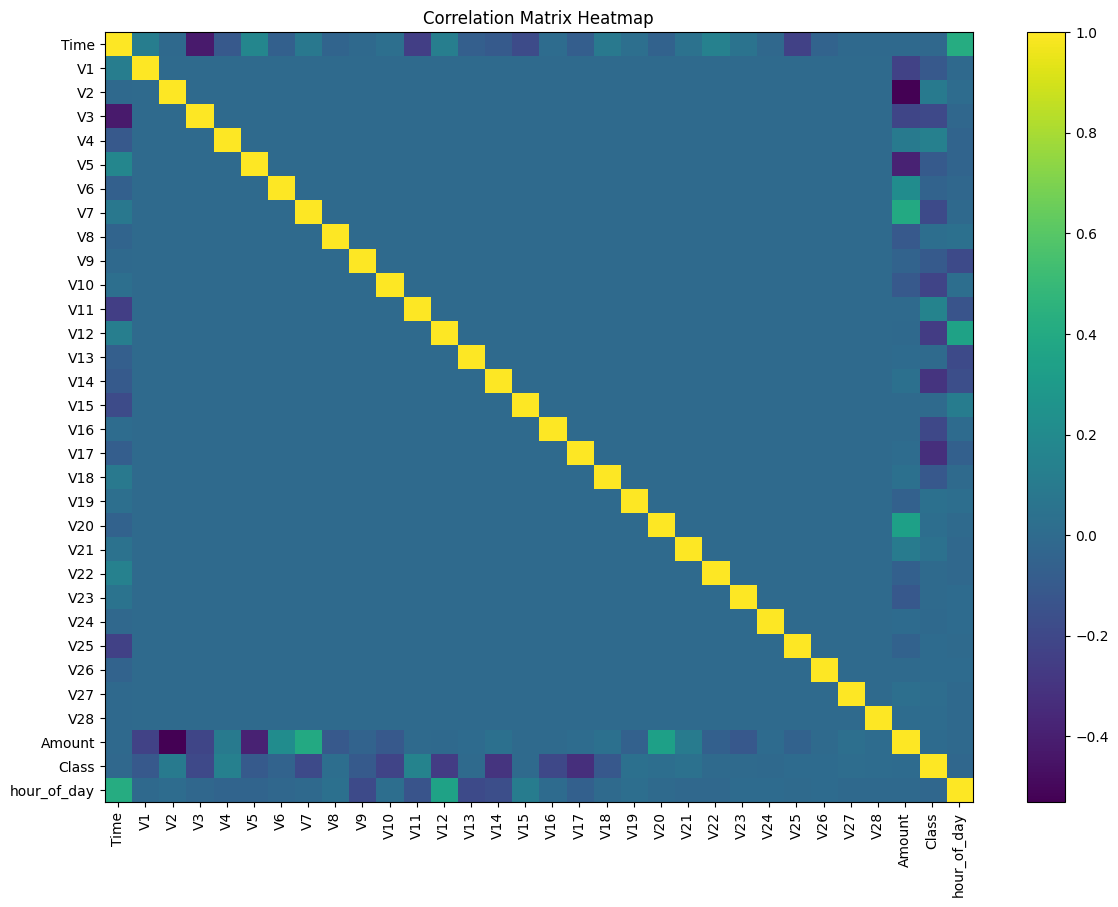

In [29]:
plt.figure(figsize=(14, 10))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix Heatmap")
plt.show()

# Correlation with target variable (Fraud = 1)

In [30]:
target_corr = corr_matrix["Class"].drop("Class").sort_values(key=abs, ascending=False)

target_corr

,Class
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965
V3,-0.1930
V7,-0.1873
V11,0.1549
V4,0.1334
V18,-0.1115


/tmp/ipykernel_3046/504300911.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr_plot.values, y=target_corr_plot.index, ax=axes[1], palette='viridis')


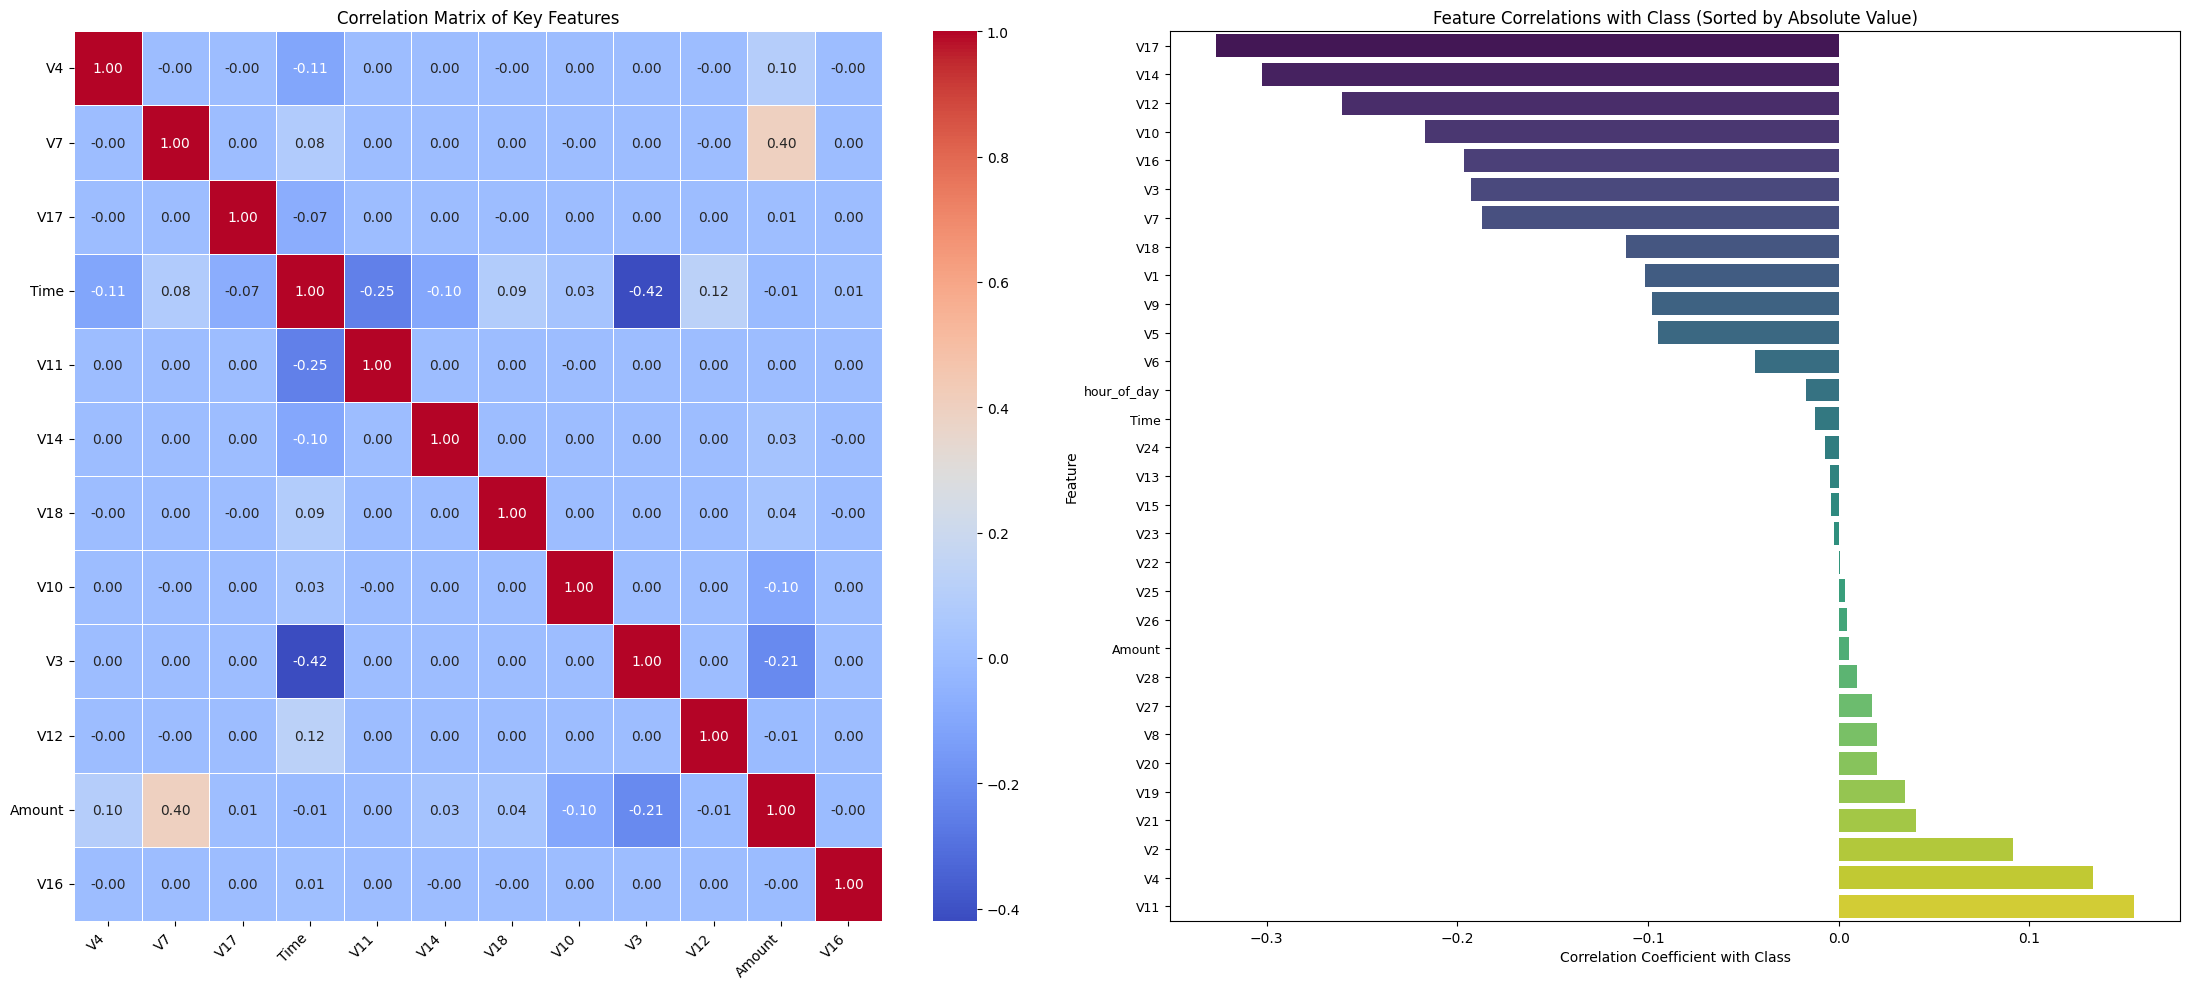

In [33]:
import seaborn as sns

# Assuming 'corr_matrix', 'target_corr', and 'df' are available from previous cells.

# Identify top features for a more focused heatmap
# Get the top 10 features correlating with 'Class' by absolute value.
top_n_features_for_heatmap = target_corr.head(10).index.tolist()

# Add 'Time' and 'Amount' to this list if they are not already in the top 10
if 'Time' not in top_n_features_for_heatmap:
    top_n_features_for_heatmap.append('Time')
if 'Amount' not in top_n_features_for_heatmap:
    top_n_features_for_heatmap.append('Amount')

# Ensure unique features (in case 'Time'/'Amount' were already in top 10)
top_n_features_for_heatmap = list(set(top_n_features_for_heatmap))

# Create a sub-correlation matrix for these selected features
# Ensure 'df' contains these columns for correlation calculation
focused_corr_matrix = df[top_n_features_for_heatmap].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 10))  # Adjust figure size for better readability

# Subplot 1: Focused Correlation Matrix Heatmap
sns.heatmap(focused_corr_matrix, ax=axes[0], cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5, cbar=True)
axes[0].set_title('Correlation Matrix of Key Features')
axes[0].set_xticklabels(focused_corr_matrix.columns, rotation=45, ha='right')
axes[0].set_yticklabels(focused_corr_matrix.columns, rotation=0)

# Subplot 2: Correlation with Target Variable (Class)
# Sort target_corr by value in ascending order for horizontal bar plot
target_corr_plot = target_corr.sort_values(ascending=True)

sns.barplot(x=target_corr_plot.values, y=target_corr_plot.index, ax=axes[1], palette='viridis')
axes[1].set_title('Feature Correlations with Class (Sorted by Absolute Value)')
axes[1].set_xlabel('Correlation Coefficient with Class')
axes[1].set_ylabel('Feature')
axes[1].tick_params(axis='y', labelsize=9)  # Adjust label size if needed

plt.tight_layout()
plt.show()

# Top correlations with fraud

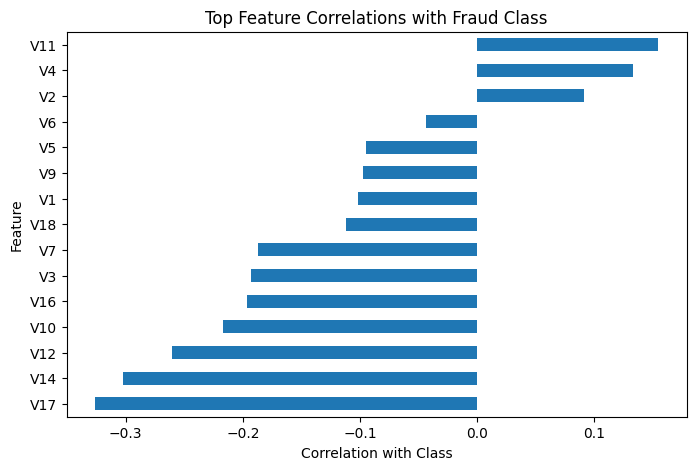

In [ ]:
top_target_corr = target_corr.head(15)

plt.figure(figsize=(8, 5))
top_target_corr.sort_values().plot(kind="barh")
plt.title("Top Feature Correlations with Fraud Class")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")
plt.show()

# Multicollinearity analysis

For this dataset, V1 through V28 are PCA-transformed features, so most of them should not be strongly collinear. However, Time and Amount may behave differently.
### Find highly correlated feature pairs

In [34]:
features_only = df.drop(columns=["Class", "Log_Amount"])

feature_corr = features_only.corr().abs()

upper_triangle = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_correlation"})
    .sort_values("abs_correlation", ascending=False)
)

high_corr_pairs.head(20)

,feature_1,feature_2,abs_correlation
85,V2,Amount,0.5314
2,Time,V3,0.4196
29,Time,hour_of_day,0.4156
210,V7,Amount,0.3973
163,V5,Amount,0.3864
311,V12,hour_of_day,0.3525
418,V20,Amount,0.3394
10,Time,V11,0.2477
24,Time,V25,0.2331
57,V1,Amount,0.2277


# Filter strong multicollinearity

In [35]:
strong_corr_pairs = high_corr_pairs[high_corr_pairs["abs_correlation"] >= 0.80]

strong_corr_pairs

,feature_1,feature_2,abs_correlation


### Visualizing Highly Correlated Feature Pairs

Although no pairs exhibited very strong multicollinearity (above 0.8), we can visualize the relationships between some of the moderately correlated pairs to understand their interaction.

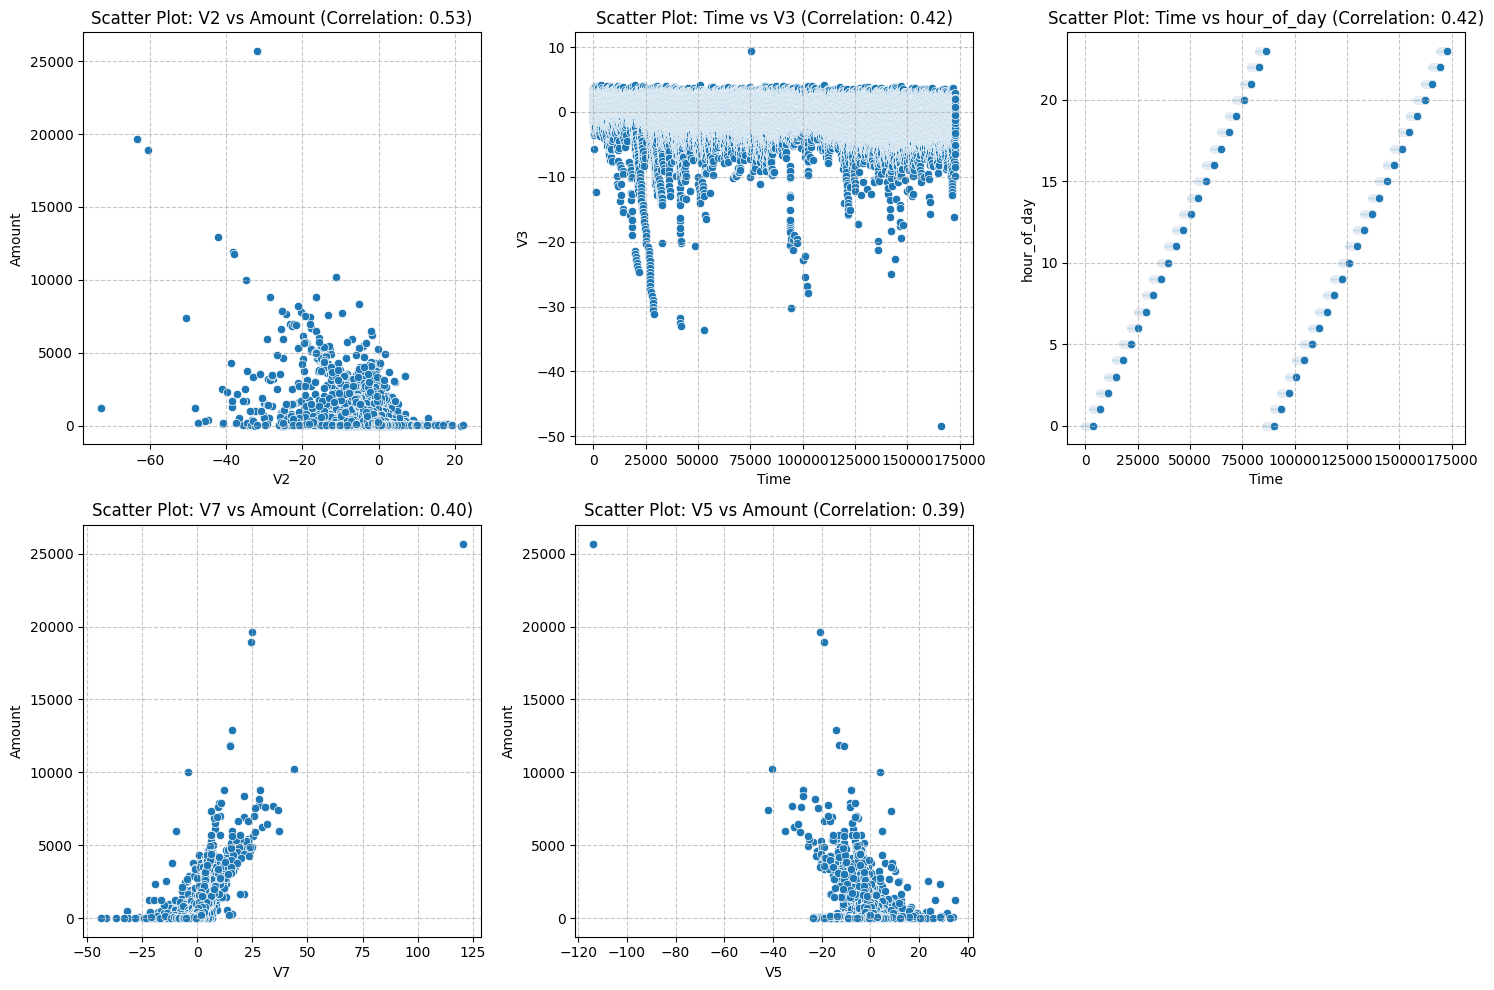

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Get the top N highly correlated pairs (e.g., top 5)
top_n_pairs = high_corr_pairs.head(5)

# Create a figure to hold multiple subplots
num_plots = len(top_n_pairs)
num_cols = 3
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))

# Flatten the axes array for easy iteration, even if there's only one row or column
axes = axes.flatten()

for idx, (original_index, row) in enumerate(top_n_pairs.iterrows()):
    feature1 = row['feature_1']
    feature2 = row['feature_2']
    abs_corr = row['abs_correlation']

    sns.scatterplot(x=df[feature1], y=df[feature2], ax=axes[idx])
    axes[idx].set_title(f'Scatter Plot: {feature1} vs {feature2} (Correlation: {abs_corr:.2f})')
    axes[idx].set_xlabel(feature1)
    axes[idx].set_ylabel(feature2)
    axes[idx].grid(True, linestyle='--', alpha=0.7)

# Hide any unused subplots
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Multicollinearity Discussion

The multicollinearity review identifies whether any independent variables are strongly correlated with each other. Strong feature-to-feature correlation can affect linear models and feature interpretation. Because most variables in this dataset are PCA-transformed components, high multicollinearity is not expected among V1–V28. However, this check is included to document feature relationships before modeling.

# VIF analysis
Variance Inflation Factor (VIF) is a statistical metric used to detect and quantify the severity of multicollinearity (correlation) among independent variables in a multiple regression model. It measures how much the variance of an estimated regression coefficient is inflated due to collinearity

For any given independent variable, VIF is calculated as:VIF_*i* = 1/(1-R_*i* ^2)
Where:R_*i* ^2 is the coefficient of determination when variable *i* is regressed against all other independent variables in the model.

How to Interpret VIF ValuesVIF values start at 1, which indicates zero correlation between a given variable and the remaining predictors\
VIF = 1: No multicollinearity.\
1 < VIF <= 5: Low to moderate multicollinearity.\
VIF > 5 or 10: High multicollinearity. \
Variables with VIFs in this range generally warrant further investigation or removal from the model\
Why High VIF Matters: When VIF is high, the standard errors of the affected coefficients balloon, causing the coefficient estimates to become highly sensitive to minor changes in the dataset. This makes it difficult—if not impossible—to isolate the precise individual effect of each predictor on the dependent variable.

Variance Inflation Factor can be computationally heavier, but this dataset is manageable.

In [43]:
vif_features = df.drop(columns=["Class", "Log_Amount"]).copy()

# Scale before VIF calculation
scaler = StandardScaler()
vif_scaled = scaler.fit_transform(vif_features)

vif_df = pd.DataFrame()
vif_df["feature"] = vif_features.columns
vif_df["VIF"] = [
    variance_inflation_factor(vif_scaled, i)
    for i in range(vif_scaled.shape[1])
]

vif_df.sort_values("VIF", ascending=False)

,feature,VIF
29,Amount,12.1169
2,V2,4.4231
7,V7,2.9367
5,V5,2.8930
0,Time,2.5426
20,V20,2.4007
3,V3,1.9766
30,hour_of_day,1.8363
1,V1,1.6619
6,V6,1.5721


In [44]:
variables_to_consider_for_elimination = vif_df[vif_df['VIF'] > 5]
print('Variables with VIF > 5 (suggesting high multicollinearity):')
display(variables_to_consider_for_elimination)

Variables with VIF > 5 (suggesting high multicollinearity):


,feature,VIF
29,Amount,12.1169


Plotting 'Amount' against these features due to high correlation and VIF: ['V2', 'V7', 'V5', 'V20', 'V1']


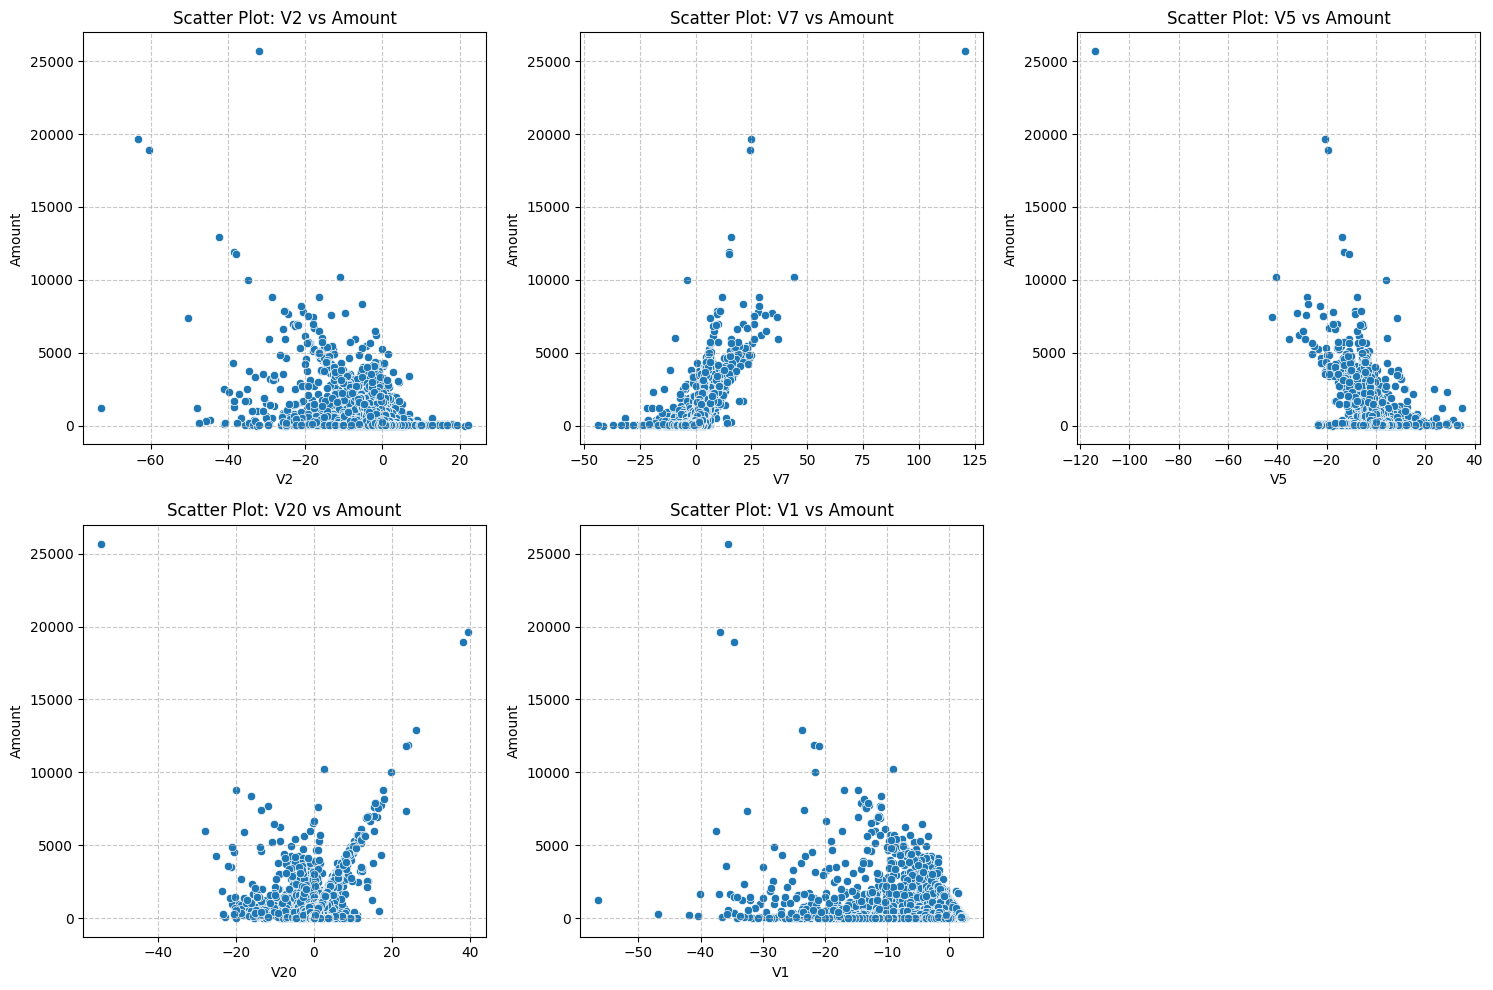

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Identify features highly correlated with 'Amount' from high_corr_pairs
amount_correlated_pairs = high_corr_pairs[(high_corr_pairs['feature_1'] == 'Amount') | (high_corr_pairs['feature_2'] == 'Amount')].head(5)

# Prepare features for plotting
plot_features = []
for index, row in amount_correlated_pairs.iterrows():
    if row['feature_1'] == 'Amount':
        plot_features.append(row['feature_2'])
    else:
        plot_features.append(row['feature_1'])

print(f"Plotting 'Amount' against these features due to high correlation and VIF: {plot_features}")

num_plots = len(plot_features)
num_cols = 3
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))

# Flatten the axes array for easy iteration, even if there's only one row or column
axes = axes.flatten()

for i, feature in enumerate(plot_features):
    sns.scatterplot(x=df[feature], y=df['Amount'], ax=axes[i])
    axes[i].set_title(f'Scatter Plot: {feature} vs Amount')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Amount')
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Hide any unused subplots
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## VIF Interpretation

Variance Inflation Factor was used to check whether any feature can be strongly explained by other features. A high VIF may indicate multicollinearity. Since V1–V28 are PCA-transformed variables, high VIF values are not expected for those features. If Time or Amount show elevated VIF, those features should be reviewed during model development.

# Amount outlier review

In [50]:
amount_q1 = df["Amount"].quantile(0.25)
amount_q3 = df["Amount"].quantile(0.75)
amount_iqr = amount_q3 - amount_q1

lower_bound = amount_q1 - 1.5 * amount_iqr
upper_bound = amount_q3 + 1.5 * amount_iqr

amount_outliers = df[(df["Amount"] < lower_bound) | (df["Amount"] > upper_bound)]

print("Amount Q1:", amount_q1)
print("Amount Q3:", amount_q3)
print("Amount IQR:", amount_iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Amount outlier count:", amount_outliers.shape[0])
print("Amount outlier percentage:", amount_outliers.shape[0] / len(df) * 100)

Amount Q1: 5.6
Amount Q3: 77.16499999999999
Amount IQR: 71.565
Lower bound: -101.7475
Upper bound: 184.5125
Amount outlier count: 31904
Amount outlier percentage: 11.201971861646658


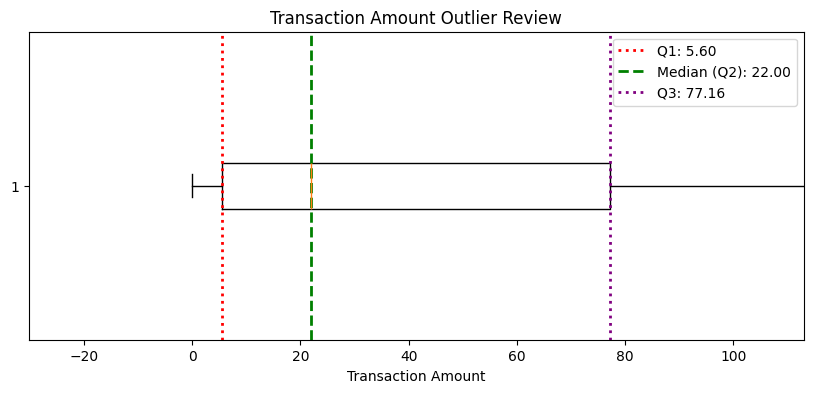

In [51]:
# Amount outlier visualization: boxplot

plt.figure(figsize=(10, 4))
plt.boxplot(df["Amount"], vert=False, showfliers=True)
plt.title("Transaction Amount Outlier Review")
plt.xlabel("Transaction Amount")

# Add quartile markers
amount_q1 = df["Amount"].quantile(0.25)
amount_median = df["Amount"].quantile(0.50)
amount_q3 = df["Amount"].quantile(0.75)

plt.axvline(amount_q1, color='red', linestyle=':', label=f'Q1: {amount_q1:,.2f}', linewidth=2)
plt.axvline(amount_median, color='green', linestyle='--', label=f'Median (Q2): {amount_median:,.2f}', linewidth=2)
plt.axvline(amount_q3, color='purple', linestyle=':', label=f'Q3: {amount_q3:,.2f}', linewidth=2)

# Set x-axis limits to zoom in around the quartiles for better visibility
plt.xlim(amount_q1 - (amount_q3 - amount_q1) * 0.5, amount_q3 + (amount_q3 - amount_q1) * 0.5) # Adjust range as needed

plt.legend()
plt.show()

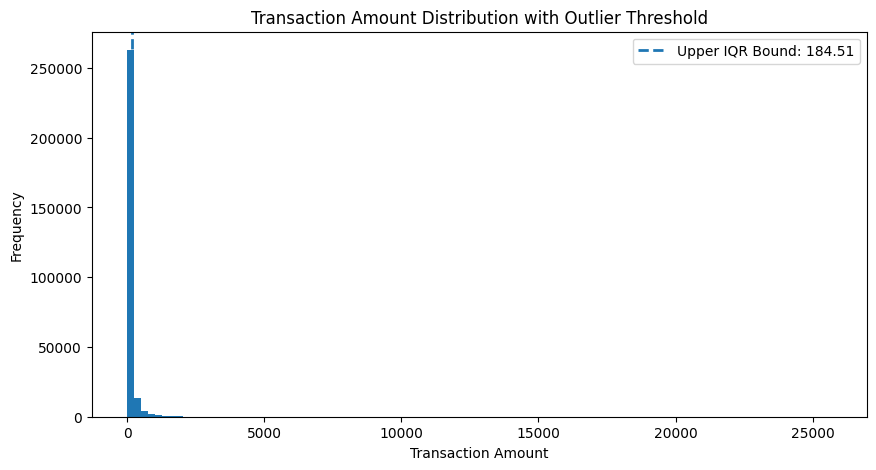

In [52]:
# Amount distribution with IQR outlier threshold

plt.figure(figsize=(10, 5))
plt.hist(df["Amount"], bins=100)
plt.axvline(upper_bound, linestyle="--", linewidth=2, label=f"Upper IQR Bound: {upper_bound:.2f}")
plt.title("Transaction Amount Distribution with Outlier Threshold")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

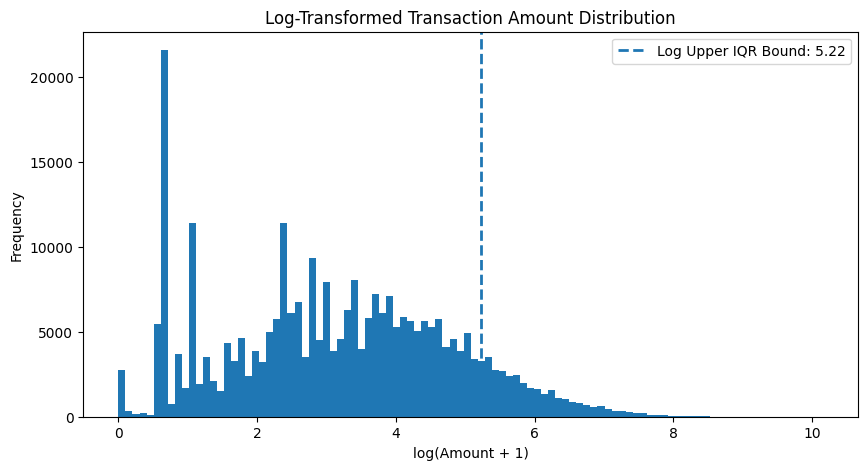

In [ ]:
# Log-transformed amount distribution with outliers identified

df["Log_Amount"] = np.log1p(df["Amount"])
log_upper_bound = np.log1p(upper_bound)

plt.figure(figsize=(10, 5))
plt.hist(df["Log_Amount"], bins=100)
plt.axvline(log_upper_bound, linestyle="--", linewidth=2, label=f"Log Upper IQR Bound: {log_upper_bound:.2f}")
plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
amount_outlier_fraud_rate = amount_outliers["Class"].mean() * 100

print(f"Fraud rate among amount outliers: {amount_outlier_fraud_rate:.4f}%")

Fraud rate among amount outliers: 0.2852%


## Amount Outlier Interpretation

The transaction amount distribution is highly right-skewed, meaning most transactions are relatively small while a smaller number of transactions have much larger values. The IQR method was used to identify unusually large transaction amounts.

These outliers should not be removed automatically because extreme transaction amounts may contain meaningful fraud signals. Instead, the outlier behavior will be documented and considered during preprocessing and model development.

# EDA summary table

In [ ]:
eda_summary = {
    "total_rows": df.shape[0],
    "total_columns": df.shape[1],
    "fraud_count": fraud_count,
    "non_fraud_count": non_fraud_count,
    "fraud_percent": fraud_percent,
    "total_missing_values": int(df.isnull().sum().sum()),
    "duplicate_rows": int(duplicate_count),
    "amount_outlier_count": int(amount_outliers.shape[0])
}

eda_summary_df = pd.DataFrame([eda_summary])
eda_summary_df

,total_rows,total_columns,fraud_count,non_fraud_count,fraud_percent,total_missing_values,duplicate_rows,amount_outlier_count
0,284807,32,492,284315,0.1727,0,1081,31904


# Export EDA results to reports in Google Drive

In [ ]:
output_folder = "/content/drive/MyDrive/Interview Node/Capstone_Project/Fraud Detection GCP Capstone/reports"

eda_summary_df.to_csv(f"{output_folder}/eda_summary.csv", index=False)
target_corr.to_csv(f"{output_folder}/target_correlations.csv")
high_corr_pairs.to_csv(f"{output_folder}/feature_correlation_pairs.csv", index=False)
vif_df.to_csv(f"{output_folder}/vif_results.csv", index=False)

print("EDA report files saved.")

EDA report files saved.


# EDA Findings Summary

The dataset contains credit card transactions with a highly imbalanced target variable. Fraud cases represent a very small fraction of the total dataset, which means accuracy alone is not an appropriate performance metric.

The EDA reviewed dataset structure, missing values, duplicate records, transaction amount distribution, time distribution, class imbalance, feature correlations, feature-to-feature collinearity, and Variance Inflation Factor.

Key modeling implications:

1. The model must be evaluated using precision, recall, F1-score, ROC-AUC, PR-AUC, and confusion matrix analysis.
2. Stratified train/test splitting is required to preserve the fraud ratio.
3. Scaling should be fitted only on the training data to avoid data leakage.
4. Class imbalance must be handled using appropriate methods such as class weighting, anomaly detection, threshold tuning, or resampling.
5. Correlation and VIF results should be documented, but PCA-transformed features V1–V28 are expected to have limited multicollinearity.
6. Outlier behavior in transaction amount should be reviewed but not automatically removed because extreme values may contain important fraud signals.